# 02 — Modeling: Baseline & Benchmarking

**Stage 3 objective:** establish a simple, interpretable benchmark (plain Logistic Regression, default settings, no resampling or class weighting) before introducing more complex models or handling class imbalance. This baseline is deliberately naive — it sets the floor that Stage 4's model/imbalance-handling comparison has to beat.

Evaluated on the **validation split** (last 6 weeks of `fraudTrain.csv`) defined in `src/preprocessing.py`. `fraudTest.csv` stays untouched.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
    roc_auc_score, confusion_matrix, precision_recall_curve, roc_curve
)

import preprocessing as pp

sns.set_style('whitegrid')
DATA_DIR = '../data'

## Load data and apply the Stage 2 split + preprocessing

In [2]:
train_raw = pp.engineer_features(pp.load_raw(f'{DATA_DIR}/fraudTrain.csv'))
test_raw = pp.engineer_features(pp.load_raw(f'{DATA_DIR}/fraudTest.csv'))

train_split, val_split = pp.temporal_train_val_split(train_raw, val_weeks=6)

X_train, y_train = pp.split_X_y(train_split)
X_val, y_val = pp.split_X_y(val_split)
X_test, y_test = pp.split_X_y(test_raw)

preprocessor = pp.build_preprocessor()
Xt_train = preprocessor.fit_transform(X_train)
Xt_val = preprocessor.transform(X_val)

print('Train:', Xt_train.shape, 'fraud:', y_train.sum(), f'({100 * y_train.mean():.3f}%)')
print('Val:  ', Xt_val.shape, 'fraud:', y_val.sum(), f'({100 * y_val.mean():.3f}%)')

Train: (1185094, 28) fraud: 6837 (0.577%)
Val:   (111581, 28) fraud: 669 (0.600%)


## Baseline: plain Logistic Regression (no class weighting, no resampling)

In [3]:
baseline_lr = LogisticRegression(max_iter=1000, random_state=42)
baseline_lr.fit(Xt_train, y_train)

val_proba = baseline_lr.predict_proba(Xt_val)[:, 1]
val_pred = (val_proba >= 0.5).astype(int)

## Evaluation metrics (validation set, default 0.5 threshold)

Deliberately **not** reporting accuracy as a headline metric — Stage 1 already showed a trivial always-legitimate classifier scores 99.4% accuracy while catching zero fraud.

In [4]:
def fraud_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    return {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, y_proba),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'fpr': fpr,
        'confusion_matrix': cm,
    }

baseline_metrics = fraud_metrics(y_val, val_pred, val_proba)

print('Baseline Logistic Regression (threshold = 0.5)')
for k, v in baseline_metrics.items():
    if k != 'confusion_matrix':
        print(f'  {k:10s}: {v:.4f}')
print('\nConfusion matrix [[TN FP] [FN TP]]:')
print(baseline_metrics['confusion_matrix'])

Baseline Logistic Regression (threshold = 0.5)
  precision : 0.0702
  recall    : 0.0060
  f1        : 0.0110
  pr_auc    : 0.2632
  roc_auc   : 0.8265
  fpr       : 0.0005

Confusion matrix [[TN FP] [FN TP]]:
[[110859     53]
 [   665      4]]


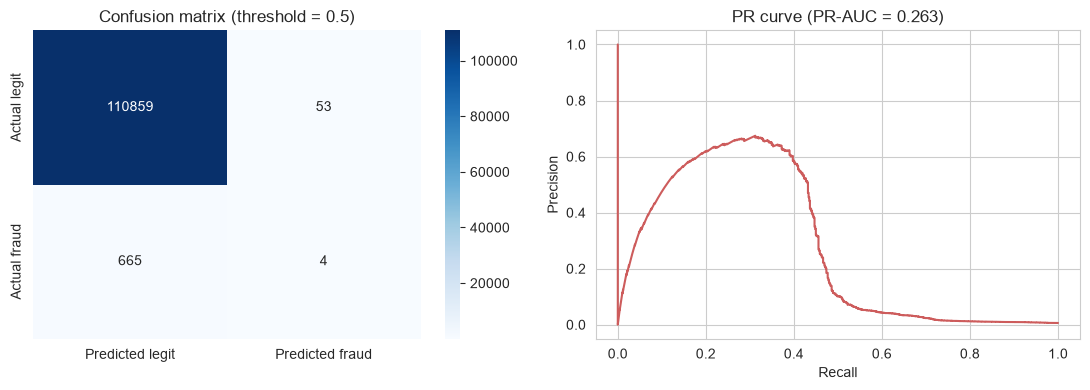

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(baseline_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted legit', 'Predicted fraud'],
            yticklabels=['Actual legit', 'Actual fraud'], ax=axes[0])
axes[0].set_title('Confusion matrix (threshold = 0.5)')

prec, rec, _ = precision_recall_curve(y_val, val_proba)
axes[1].plot(rec, prec, color='indianred')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f"PR curve (PR-AUC = {baseline_metrics['pr_auc']:.3f})")

plt.tight_layout()
plt.show()

## Baseline takeaway

This result is the floor, not the ceiling. At the default 0.5 threshold with no imbalance handling, plain Logistic Regression's recall reflects how conservative an untouched-imbalance model is about predicting the rare class — most probabilities never cross 0.5. PR-AUC and ROC-AUC (threshold-independent) are the numbers that matter most for comparing this baseline against the class-weighted / resampled / tree-based models in Stage 4, since the operating threshold itself is not decided until Stage 5.

## Stage 4a — Imbalance-Handling Comparison

Using Logistic Regression as a cheap, fast representative model, compare three ways of handling the class imbalance, empirically rather than by assumption:

1. **Original distribution** (already computed above as the Stage 3 baseline).
2. **Class weighting** (`class_weight='balanced'`) - reweights the loss, no synthetic data.
3. **SMOTE** (train-only oversampling to 10% fraud) - generates synthetic minority examples. At 0.578% real fraud, even a modest 10% target means most of the resulting minority-class rows are synthetic, not real transactions - a known SMOTE risk on this rare a class, evaluated here rather than assumed away.

In [6]:
import sys
sys.path.insert(0, '../src')
import train as tr
import evaluate as ev

results = {'Original distribution': baseline_metrics}

# Class weighting
lr_weighted = tr.build_models(class_weighted=True)['Logistic Regression']
lr_weighted.fit(Xt_train, y_train)
proba_w = lr_weighted.predict_proba(Xt_val)[:, 1]
pred_w = (proba_w >= 0.5).astype(int)
results['Class-weighted'] = ev.fraud_metrics(y_val, pred_w, proba_w)

# SMOTE (train-only)
Xt_train_sm, y_train_sm = tr.apply_smote(Xt_train, y_train, sampling_strategy=0.1)
print('SMOTE-resampled train shape:', Xt_train_sm.shape,
      'fraud:', int(y_train_sm.sum()), f'({100 * y_train_sm.mean():.2f}%)')
lr_smote = tr.build_models(class_weighted=False)['Logistic Regression']
lr_smote.fit(Xt_train_sm, y_train_sm)
proba_sm = lr_smote.predict_proba(Xt_val)[:, 1]
pred_sm = (proba_sm >= 0.5).astype(int)
results['SMOTE (10% target)'] = ev.fraud_metrics(y_val, pred_sm, proba_sm)

ev.metrics_table(results)

SMOTE-resampled train shape: (1296082, 28) fraud: 117825 (9.09%)


,pr_auc,roc_auc,precision,recall,f1,fpr
model,,,,,,
Original distribution,0.2632,0.8265,0.0702,0.0060,0.0110,0.0005
Class-weighted,0.1833,0.9122,0.0368,0.7549,0.0702,0.1190
SMOTE (10% target),0.2552,0.8987,0.3900,0.5456,0.4548,0.0051


### Stage 4a takeaway

For Logistic Regression specifically, the result is more nuanced than 'resampling helps': by **PR-AUC** (threshold-independent, the fairer comparison) the three strategies are close - Original 0.263, SMOTE 0.255, Class-weighted 0.183 - with the untouched original distribution actually ranking transactions very slightly better than either intervention. What class weighting and SMOTE really change is **where the 0.5 threshold lands**: class weighting pushes recall from 0.6% to 75.5% (at the cost of precision and a 100x higher FPR), and SMOTE lands in between (54.6% recall, much better precision than class-weighting because it doesn't over-correct as hard).

Takeaway: for a linear model on this data, imbalance handling is mostly a **threshold/calibration** story, not a ranking-quality story - reinforcing why Stage 5 (threshold optimization) matters independently of this choice. This is exactly the 'don't assume resampling helps, check empirically' principle from the project plan - here it doesn't clearly beat the alternatives for Logistic Regression specifically.

## Stage 4b — Model Comparison: Logistic Regression vs. Random Forest vs. XGBoost

Stage 4a showed no strategy is a clean PR-AUC winner for Logistic Regression - the differences are mostly about threshold behavior, not ranking quality. Class weighting (`class_weight='balanced'` / XGBoost's `scale_pos_weight`) is used here for all three models anyway, for a practical reason: it's a zero-cost, no-synthetic-data way to keep the model from ignoring the minority class outright, and unlike SMOTE it doesn't require picking an arbitrary oversampling ratio. The real test is whether it holds up for the tree-based models too - not assumed, checked below.

In [7]:
USE_CLASS_WEIGHTING = True  # set based on the Stage 4a comparison

spw = tr.class_weight_ratio(y_train)
models = tr.build_models(class_weighted=USE_CLASS_WEIGHTING, scale_pos_weight=spw)

model_results = {}
model_probas = {}

for name, model in models.items():
    model.fit(Xt_train, y_train)
    proba = model.predict_proba(Xt_val)[:, 1]
    pred = (proba >= 0.5).astype(int)
    model_results[name] = ev.fraud_metrics(y_val, pred, proba)
    model_probas[name] = proba
    print(f'{name} done.')

comparison_table = ev.metrics_table(model_results)
comparison_table

Logistic Regression done.


Random Forest done.


XGBoost done.


,pr_auc,roc_auc,precision,recall,f1,fpr
model,,,,,,
Logistic Regression,0.1833,0.9122,0.0368,0.7549,0.0702,0.1190
Random Forest,0.9126,0.9918,0.9076,0.8371,0.8709,0.0005
XGBoost,0.9149,0.9987,0.4337,0.9477,0.5950,0.0075


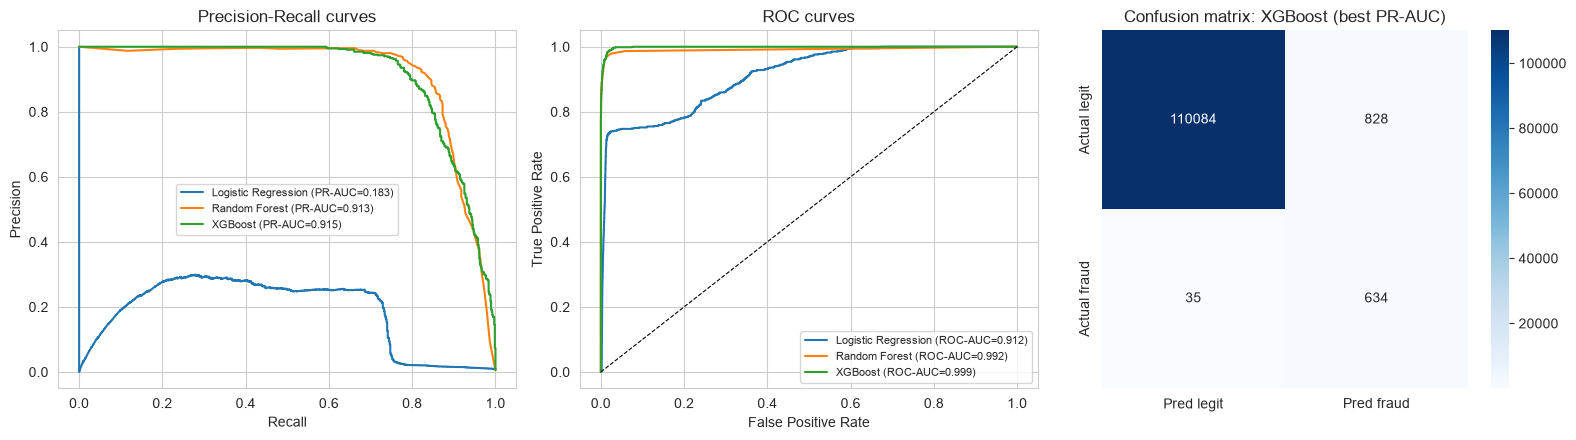

Best model by PR-AUC: XGBoost


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for name, m in model_results.items():
    p, r, _ = precision_recall_curve(y_val, model_probas[name])
    axes[0].plot(r, p, label=f"{name} (PR-AUC={m['pr_auc']:.3f})")
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].set_title('Precision-Recall curves')
axes[0].legend(fontsize=8)

for name, m in model_results.items():
    fpr_curve, tpr_curve, _ = roc_curve(y_val, model_probas[name])
    axes[1].plot(fpr_curve, tpr_curve, label=f"{name} (ROC-AUC={m['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate'); axes[1].set_title('ROC curves')
axes[1].legend(fontsize=8)

best_model_name = comparison_table['pr_auc'].idxmax()
sns.heatmap(model_results[best_model_name]['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred legit', 'Pred fraud'], yticklabels=['Actual legit', 'Actual fraud'], ax=axes[2])
axes[2].set_title(f'Confusion matrix: {best_model_name} (best PR-AUC)')

plt.tight_layout()
plt.show()
print('Best model by PR-AUC:', best_model_name)

### Stage 4b takeaway

Both tree-based models dominate Logistic Regression by a wide margin: **Random Forest** reaches PR-AUC 0.913 / ROC-AUC 0.992 with precision 0.908 and recall 0.837 at the default threshold - a strong, well-balanced result straight out of the box. **XGBoost** reaches the highest PR-AUC (0.915) and ROC-AUC (0.999), with very high recall (0.948) but much lower precision (0.434) at 0.5 - meaning it ranks transactions best of all three but, at this default threshold, trades a lot of false positives for that recall.

Neither tree model's default-threshold precision/recall is necessarily the number to ship - that's Stage 5's job. What matters here is the model choice: **XGBoost and Random Forest are both strong candidates** (Logistic Regression is decisively out, even with imbalance handling), and the final pick between them should come from Stage 5's threshold analysis and Stage 6's investigator-capacity simulation, not from PR-AUC alone.